In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: Arnav Jade , Aman Sharma
- PRN : 2508401288018 , 250840128009
- Date: 15/11/2025

# Deep Neural Network
## Assignment A05

## Tensor Flow
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [14]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import warnings;warnings.filterwarnings('ignore')
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

In [15]:
###-----------------
### Global Variables
###-----------------
inpDir = os.path.join('..', '..', 'input')
outDir = '../output'
modelDir = '../models'
subDir = 'fashion_mnist'
altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [16]:
###-----------------
### Hyper Parameters
###-----------------
BATCH_SIZE = 64 # mini batch size (number of rows)
TEST_SIZE = 0.2
TRAIN_SIZE = int(18*BATCH_SIZE)
EPOCHS = 200 # number of epochs
ALPHA = 0.001 # learning rate
PATIENCE = 20 #Early Stopping
WEIGHT_DECAY=0.001 #AdamW
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-16

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [17]:
train_filename = (r'C:\Users\dai\PycharmProjects\JupyterProject\Assignments\fashion-mnist_test.csv')
test_filename = (r'C:\Users\dai\PycharmProjects\JupyterProject\Assignments\fashion-mnist_test.csv')

train_df = pd.read_csv(train_filename)
test_df = pd.read_csv(test_filename)

In [18]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
train_df.shape, test_df.shape

((10000, 785), (10000, 785))

In [20]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [21]:
train_df['label'].unique()

array([0, 1, 2, 3, 8, 6, 5, 4, 7, 9])

In [22]:
X_train = train_df.drop('label', axis = 1).to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df.drop('label', axis = 1).to_numpy()
y_test = test_df['label'].to_numpy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((10000, 784), (10000, 784), (10000,), (10000,))

In [23]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [24]:
mm=MinMaxScaler()
X_train = mm.fit_transform(X_train)
X_test = mm.transform(X_test)

In [25]:
le=LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [26]:
type(X_train), type(X_test), type(y_train), type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

## Converting to Dataset

In [27]:
train_ds=tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds=tf.data.Dataset.from_tensor_slices((X_test, y_test))

In [28]:
train_ds=train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds=test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [29]:
train_ds=train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds=test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [30]:
for features, labels in train_ds.take(5):
    print(features.shape,labels.shape)

(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)
(64, 784) (64,)


In [31]:
next(iter(train_ds))

(<tf.Tensor: shape=(64, 784), dtype=float64, numpy=
 array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.01376147, ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(64, 784))>,
 <tf.Tensor: shape=(64,), dtype=int64, numpy=
 array([8, 7, 8, 5, 0, 5, 0, 8, 2, 4, 0, 0, 0, 5, 3, 0, 1, 2, 1, 3, 9, 9,
        6, 6, 1, 7, 2, 4, 6, 8, 7, 2, 0, 1, 5, 1, 0, 7, 3, 9, 5, 6, 7, 4,
        3, 4, 4, 3, 7, 1, 7, 9, 2, 6, 3, 1, 0, 7, 2, 3, 5, 0, 7, 5])>)

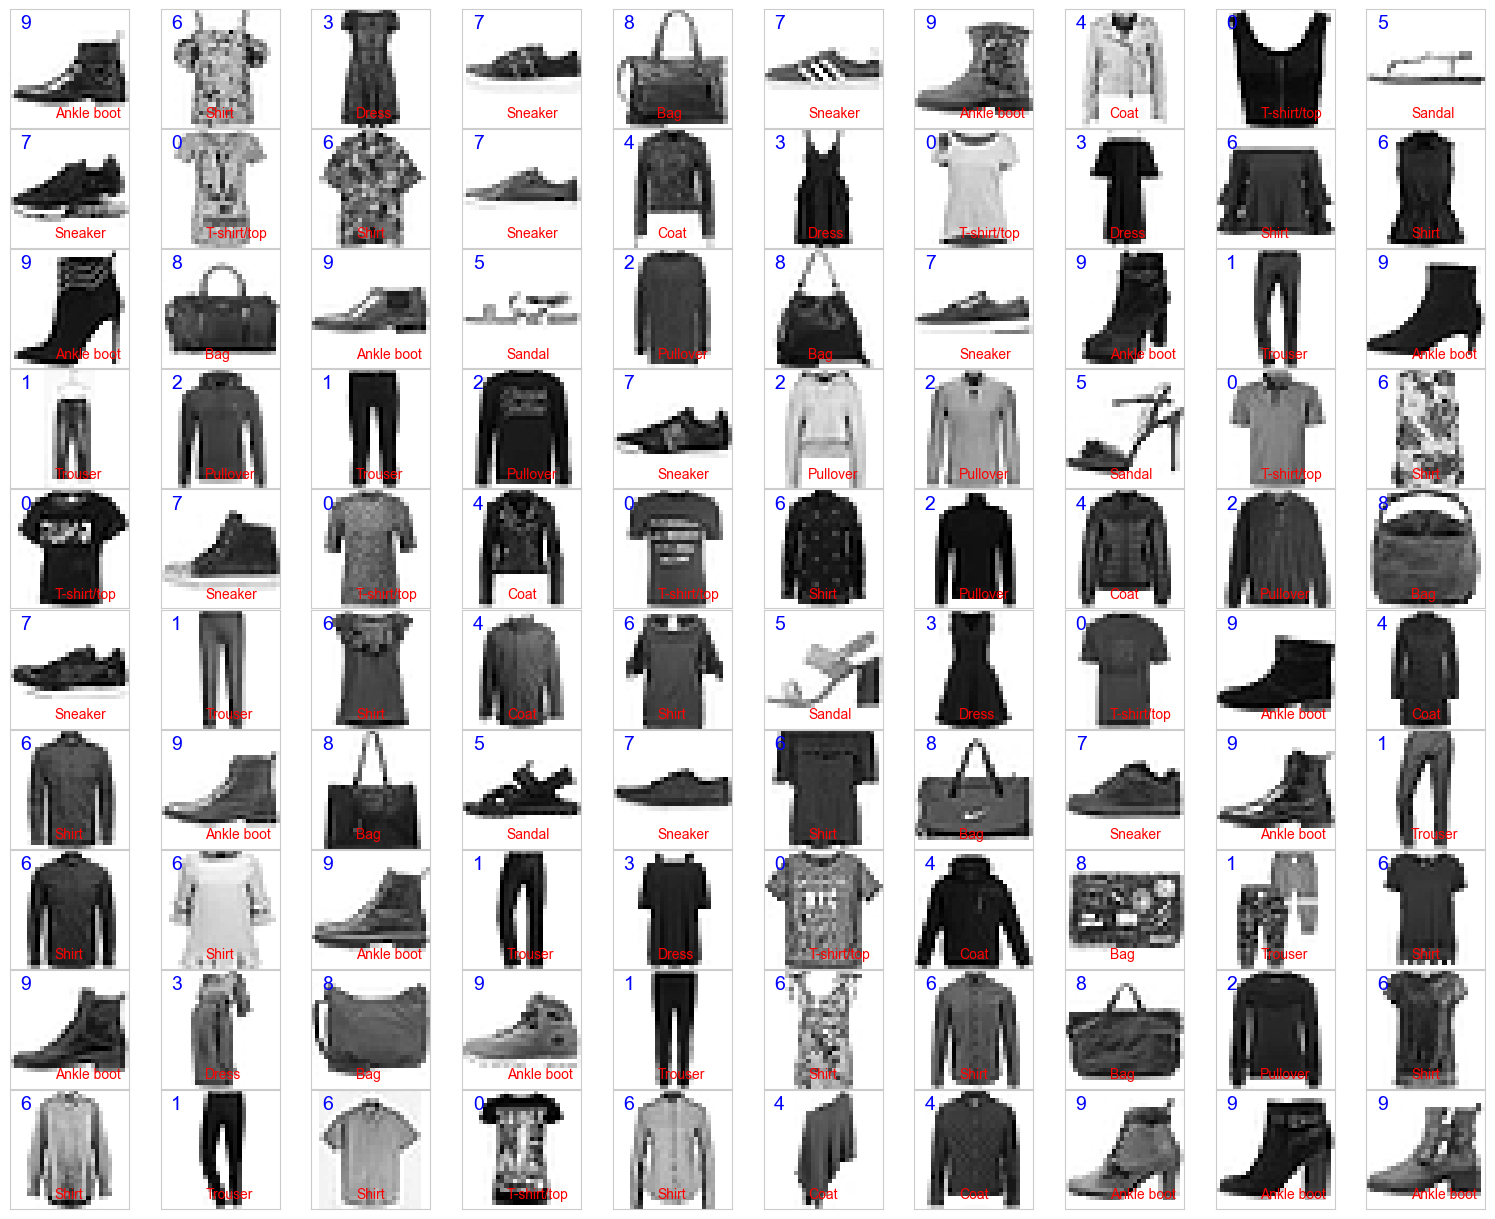

In [32]:
plot_df=train_df.sample(n=100)
fig=plt.figure(figsize = (15,12))
fig.subplots_adjust(left=0,right=1,bottom=0,top=1,hspace=0.01,wspace=0.05)
i=0
for _,row in plot_df.iterrows():
    i=i+1
    image=row.values[1:].reshape(28,28)
    ax=fig.add_subplot(10,10,(i),xticks=[],yticks=[])
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest')
    ax.text(2,4,str(row[0]),color='b',fontsize='14')
    ax.text(10,25,class_names[(row[0])],color='r',fontsize='10')

plt.show()

## Define Model

In [33]:
initializer=tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer=tf.keras.regularizers.L2(0.05)

dor1 = 0.2
dor2 = 0.3

model=tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                           #Set-1
                           tf.keras.layers.Dense(196,kernel_initializer=initializer,#kernel_regularizer=regularizer
                                                 ),
                           tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor1),

                           #Set-2
                           tf.keras.layers.Dense(49,kernel_initializer=initializer,#kernel_regularizer=regularizer
                                                 ),
                           tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor2),
                           tf.keras.layers.Dense(10,kernel_initializer=initializer,#kernel_regularizer=regularizer
                                                 )])

In [34]:
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
model.compile(optimizer=optimizer,loss=loss_fn,metrics=['accuracy'])

In [35]:
history=model.fit(train_ds,validation_data=test_ds,epochs=EPOCHS)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6840 - loss: 0.9039 - val_accuracy: 0.8196 - val_loss: 0.5453
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7869 - loss: 0.6037 - val_accuracy: 0.8379 - val_loss: 0.4691
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8129 - loss: 0.5352 - val_accuracy: 0.8486 - val_loss: 0.4297
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8278 - loss: 0.4903 - val_accuracy: 0.8521 - val_loss: 0.4129
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8376 - loss: 0.4655 - val_accuracy: 0.8622 - val_loss: 0.3856
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8405 - loss: 0.4486 - val_accuracy: 0.8764 - val_loss: 0.3499
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8453 - loss: 0.4294 - val_accuracy: 0.8731 - val_loss: 0.3504
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8527 - loss: 0.4131 - val_accura

In [36]:
model.evaluate(train_ds, verbose=2) #[0.2448723465204239, 0.8982571959495544]
model.evaluate(test_ds, verbose=2) #[0.31056174635887146, 0.8735536932945251]

157/157 - 1s - 4ms/step - accuracy: 0.9158 - loss: 0.2160
157/157 - 1s - 4ms/step - accuracy: 0.9158 - loss: 0.2160


[0.2160232663154602, 0.9157999753952026]

In [37]:
y_true,y_pred=[],[]
for feat,lbls in train_ds: #feat=features, lbls=labels
    pred=model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true,y_pred):.4f}')
print(classification_report(y_true,y_pred))

Accuracy: 0.9158
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.77      0.93      0.84      1000
           3       0.88      0.96      0.92      1000
           4       0.89      0.81      0.85      1000
           5       0.99      0.99      0.99      1000
           6       0.83      0.72      0.77      1000
           7       0.96      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



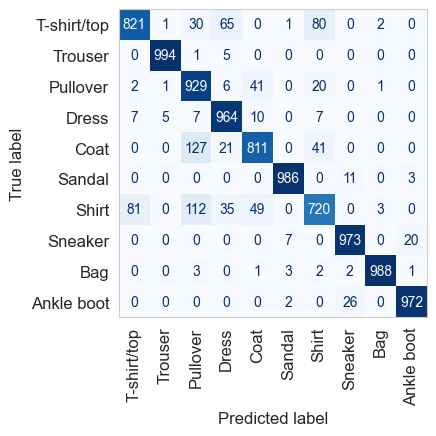

In [38]:
confusion_matrix(y_true,y_pred)
fn_plot_confusion_matrix(y_true,y_pred,class_names)

In [39]:
y_true,y_pred=[],[]
for feat,lbls in test_ds: #feat=features, lbls=labels
    pred=model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true,y_pred):.4f}')
print(classification_report(y_true,y_pred))

Accuracy: 0.9158
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.77      0.93      0.84      1000
           3       0.88      0.96      0.92      1000
           4       0.89      0.81      0.85      1000
           5       0.99      0.99      0.99      1000
           6       0.83      0.72      0.77      1000
           7       0.96      0.97      0.97      1000
           8       0.99      0.99      0.99      1000
           9       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



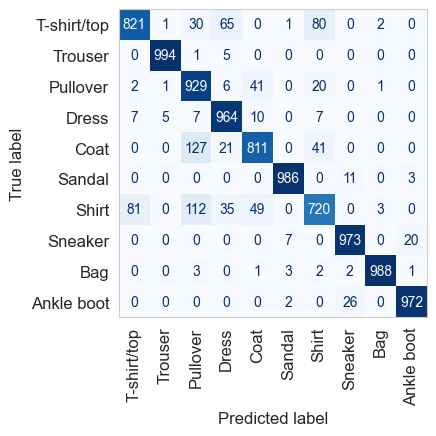

In [40]:
confusion_matrix(y_true,y_pred)
fn_plot_confusion_matrix(y_true,y_pred,class_names)

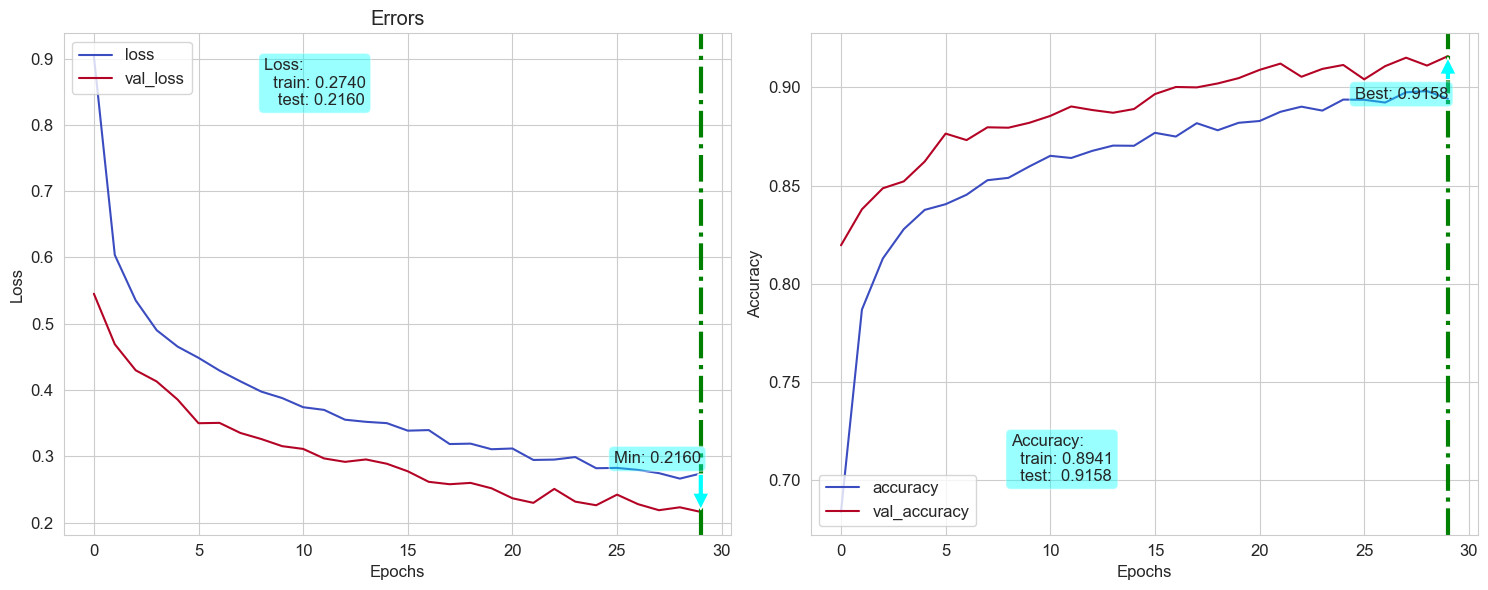

In [41]:
loss_df=pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [42]:
initializer=tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer=tf.keras.regularizers.L2(0.05)

dor1 = 0.2
dor2 = 0.3

model=tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                           #Set-1
                           tf.keras.layers.Dense(196,kernel_initializer=initializer, activation='relu'
                                                 #kernel_regularizer=regularizer
                                                 ),
                           # tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor1),

                           #Set-2
                           tf.keras.layers.Dense(49,kernel_initializer=initializer, activation='softmax'
                                                 #kernel_regularizer=regularizer
                                                 ),
                           # tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor2),
                           tf.keras.layers.Dense(10,kernel_initializer=initializer,#kernel_regularizer=regularizer
                                                 )])

In [43]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [44]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3096 - loss: 2.1096 - val_accuracy: 0.4881 - val_loss: 1.9920
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4124 - loss: 1.9322 - val_accuracy: 0.5537 - val_loss: 1.8235
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4632 - loss: 1.7886 - val_accuracy: 0.6406 - val_loss: 1.6644
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4778 - loss: 1.6650 - val_accuracy: 0.6446 - val_loss: 1.5407
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4917 - loss: 1.5535 - val_accuracy: 0.6536 - val_loss: 1.4200
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4859 - loss: 1.4882 - val_accuracy: 0.6579 - val_loss: 1.3250
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4970 - loss: 1.4197 - val_accuracy: 0.6678 - val_loss: 1.2507
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4892 - loss: 1.3830 - val_accuracy: 0.

In [45]:
model.evaluate(train_ds, verbose=2)  #[0.2448723465204239, 0.8982571959495544]
model.evaluate(test_ds, verbose=2)  #[0.31056174635887146, 0.8735536932945251]

157/157 - 1s - 5ms/step - accuracy: 0.7598 - loss: 0.6745
157/157 - 0s - 3ms/step - accuracy: 0.7598 - loss: 0.6745


[0.6744526028633118, 0.7598000168800354]

In [46]:
y_true, y_pred = [], []
for feat, lbls in train_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.7598
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1000
           1       1.00      0.99      0.99      1000
           2       0.55      0.28      0.37      1000
           3       0.92      0.95      0.94      1000
           4       0.53      0.86      0.65      1000
           5       0.58      0.62      0.60      1000
           6       0.79      0.49      0.60      1000
           7       0.59      0.53      0.56      1000
           8       0.99      0.98      0.98      1000
           9       0.97      0.99      0.98      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



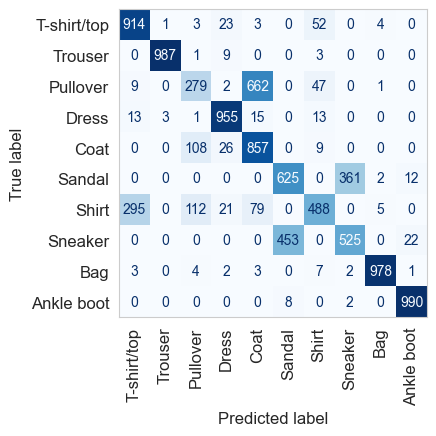

In [47]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

In [48]:
y_true, y_pred = [], []
for feat, lbls in test_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.7598
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      1000
           1       1.00      0.99      0.99      1000
           2       0.55      0.28      0.37      1000
           3       0.92      0.95      0.94      1000
           4       0.53      0.86      0.65      1000
           5       0.58      0.62      0.60      1000
           6       0.79      0.49      0.60      1000
           7       0.59      0.53      0.56      1000
           8       0.99      0.98      0.98      1000
           9       0.97      0.99      0.98      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



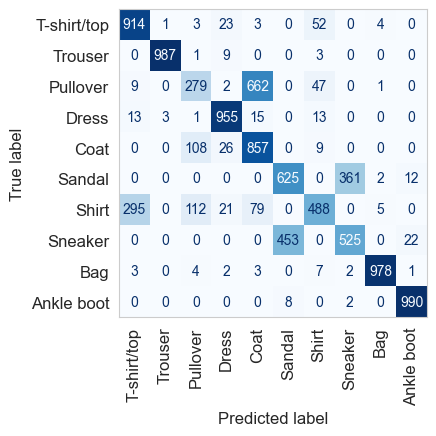

In [49]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

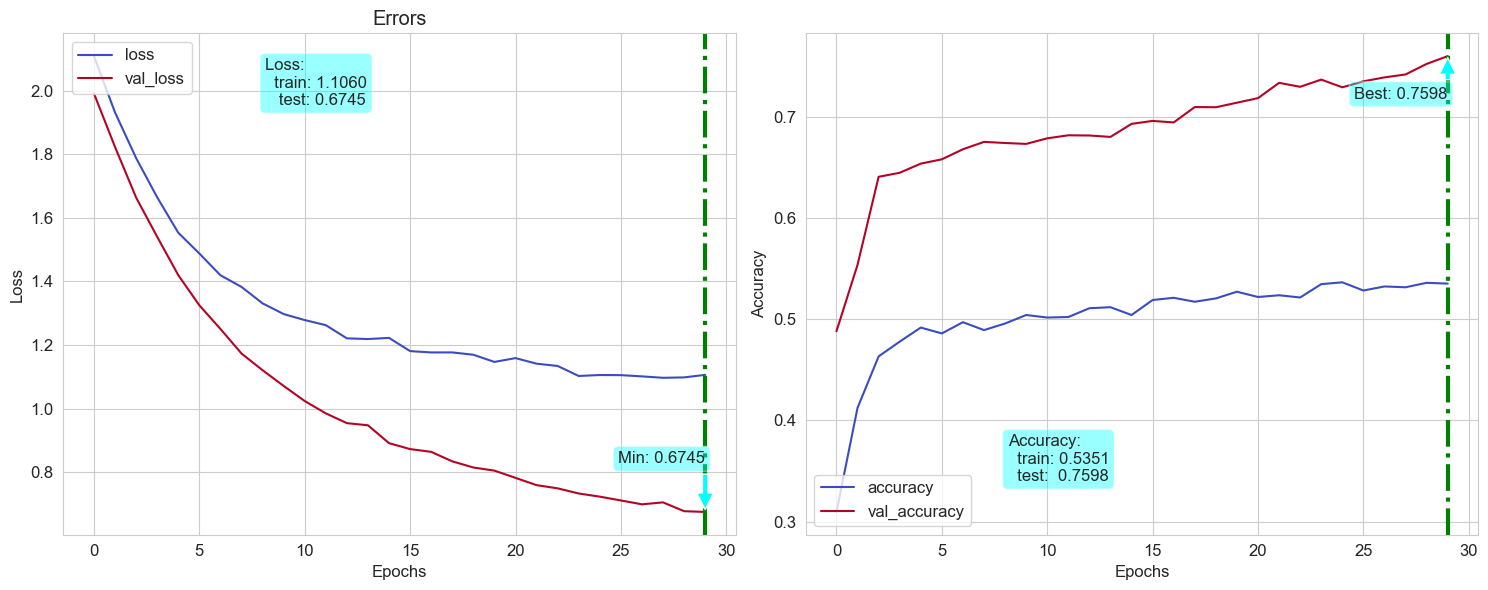

In [50]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [51]:
initializer=tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer=tf.keras.regularizers.L2(0.05)

dor1 = 0.1
dor2 = 0.2

model=tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                           #Set-1
                           tf.keras.layers.Dense(196,kernel_initializer=initializer, activation='relu'
                                                 #kernel_regularizer=regularizer
                                                 ),
                           # tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor1),

                           #Set-2
                           tf.keras.layers.Dense(49,kernel_initializer=initializer,
                                                 #kernel_regularizer=regularizer
                                                 ),
                           tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor2),
                           tf.keras.layers.Dense(10,kernel_initializer=initializer,#kernel_regularizer=regularizer
                                                 )])

In [52]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)

In [53]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7050 - loss: 0.8505 - val_accuracy: 0.8231 - val_loss: 0.5244
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8034 - loss: 0.5614 - val_accuracy: 0.8478 - val_loss: 0.4421
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8305 - loss: 0.4863 - val_accuracy: 0.8597 - val_loss: 0.4042
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8426 - loss: 0.4443 - val_accuracy: 0.8684 - val_loss: 0.3708
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8562 - loss: 0.4057 - val_accuracy: 0.8738 - val_loss: 0.3474
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8618 - loss: 0.3806 - val_accuracy: 0.8761 - val_loss: 0.3379
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8664 - loss: 0.3704 - val_accuracy: 0.8803 - val_loss: 0.3178
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8735 - loss: 0.3482 - val_accuracy: 0.

In [54]:
model.evaluate(train_ds, verbose=2)  #[0.2448723465204239, 0.8982571959495544]
model.evaluate(test_ds, verbose=2)  #[0.31056174635887146, 0.8735536932945251]

157/157 - 0s - 2ms/step - accuracy: 0.9501 - loss: 0.1340
157/157 - 0s - 2ms/step - accuracy: 0.9501 - loss: 0.1340


[0.13396906852722168, 0.9501000046730042]

In [55]:
y_true, y_pred = [], []
for feat, lbls in train_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9501
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1000
           1       1.00      1.00      1.00      1000
           2       0.91      0.90      0.91      1000
           3       0.93      0.99      0.96      1000
           4       0.89      0.91      0.90      1000
           5       0.99      1.00      0.99      1000
           6       0.91      0.82      0.86      1000
           7       1.00      0.96      0.98      1000
           8       1.00      1.00      1.00      1000
           9       0.97      0.99      0.98      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



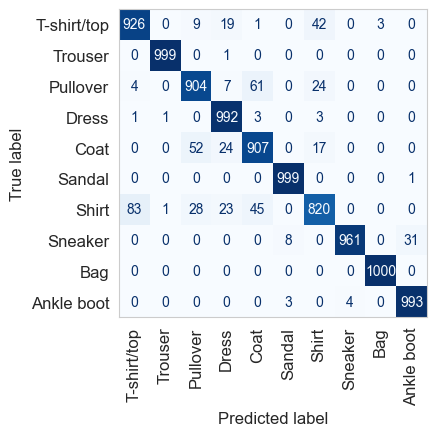

In [56]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

In [57]:
y_true, y_pred = [], []
for feat, lbls in test_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9501
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1000
           1       1.00      1.00      1.00      1000
           2       0.91      0.90      0.91      1000
           3       0.93      0.99      0.96      1000
           4       0.89      0.91      0.90      1000
           5       0.99      1.00      0.99      1000
           6       0.91      0.82      0.86      1000
           7       1.00      0.96      0.98      1000
           8       1.00      1.00      1.00      1000
           9       0.97      0.99      0.98      1000

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



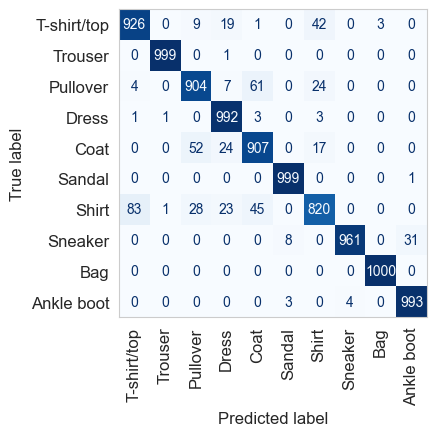

In [58]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

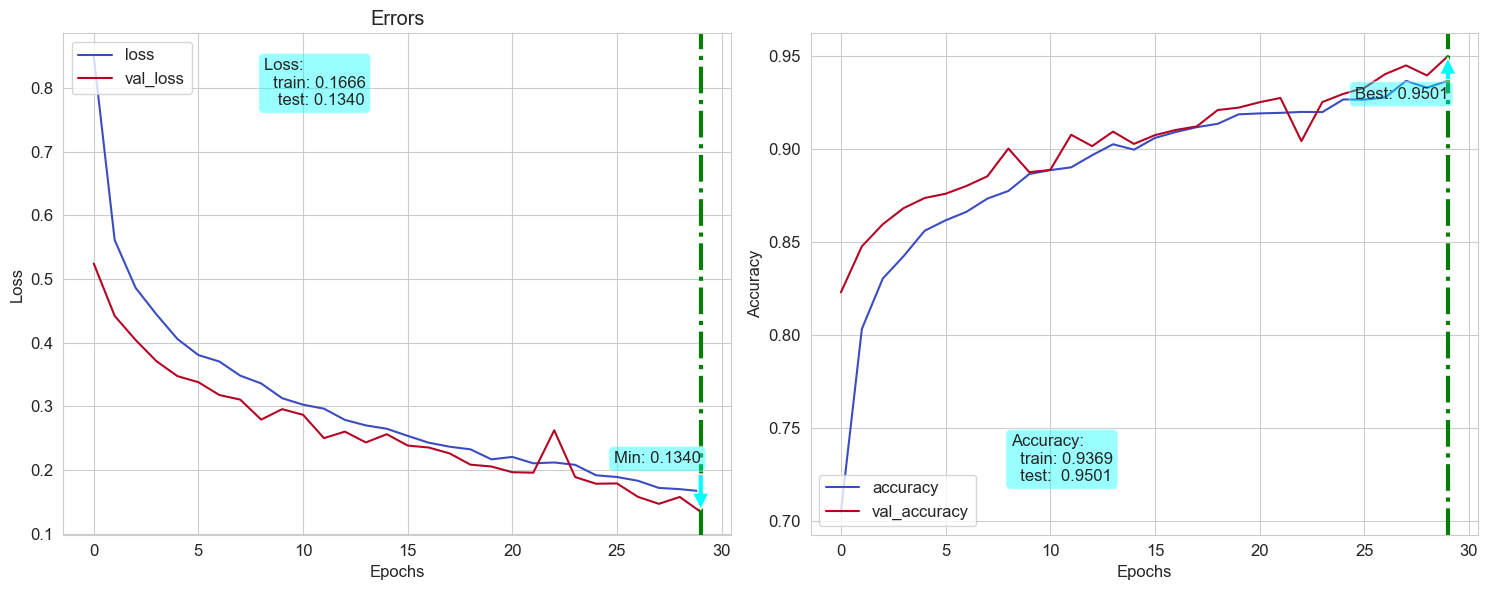

In [59]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [60]:
initializer=tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer=tf.keras.regularizers.L2(0.05)

dor1 = 0.1
dor2 = 0.2

model=tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                           #Set-1
                           tf.keras.layers.Dense(196,kernel_initializer=initializer, activation='relu'
                                                 # kernel_regularizer=regularizer
                                                 ),
                           # tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor1),

                           #Set-2
                           tf.keras.layers.Dense(49,kernel_initializer=initializer, activation='relu'
                                                 # kernel_regularizer=regularizer
                                                 ),
                           # tf.keras.layers.LeakyReLU(),
                           tf.keras.layers.Dropout(dor2),
                           tf.keras.layers.Dense(10,kernel_initializer=initializer
                           # kernel_regularizer=regularizer
                                                 )])

In [61]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6832 - loss: 0.9171 - val_accuracy: 0.8148 - val_loss: 0.5450
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7962 - loss: 0.5834 - val_accuracy: 0.8442 - val_loss: 0.4481
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8222 - loss: 0.5062 - val_accuracy: 0.8605 - val_loss: 0.3947
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8391 - loss: 0.4569 - val_accuracy: 0.8662 - val_loss: 0.3755
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8475 - loss: 0.4233 - val_accuracy: 0.8764 - val_loss: 0.3417
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8560 - loss: 0.4021 - val_accuracy: 0.8801 - val_loss: 0.3274
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8621 - loss: 0.3768 - val_accuracy: 0.8874 - val_loss: 0.3034
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8705 - loss: 0.3505 - val_accuracy: 0.

In [62]:
model.evaluate(train_ds, verbose=2)  #[0.2448723465204239, 0.8982571959495544]
model.evaluate(test_ds, verbose=2)  #[0.31056174635887146, 0.8735536932945251]

157/157 - 0s - 2ms/step - accuracy: 0.9340 - loss: 0.1655
157/157 - 0s - 2ms/step - accuracy: 0.9340 - loss: 0.1655


[0.1654728502035141, 0.9340000152587891]

In [63]:
y_true, y_pred = [], []
for feat, lbls in train_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9340
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1000
           1       1.00      1.00      1.00      1000
           2       0.89      0.83      0.86      1000
           3       0.93      0.98      0.96      1000
           4       0.80      0.93      0.86      1000
           5       0.97      1.00      0.99      1000
           6       0.93      0.71      0.80      1000
           7       0.99      0.97      0.98      1000
           8       1.00      0.99      1.00      1000
           9       0.99      0.98      0.99      1000

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000



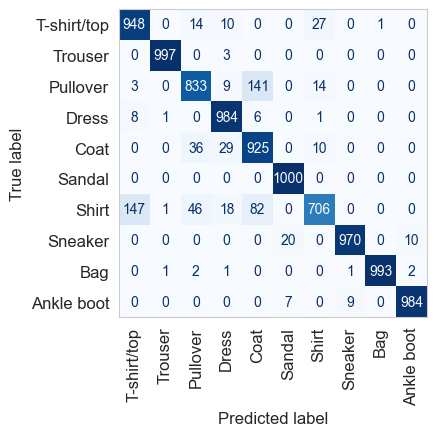

In [64]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

In [65]:
y_true, y_pred = [], []
for feat, lbls in test_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9340
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1000
           1       1.00      1.00      1.00      1000
           2       0.89      0.83      0.86      1000
           3       0.93      0.98      0.96      1000
           4       0.80      0.93      0.86      1000
           5       0.97      1.00      0.99      1000
           6       0.93      0.71      0.80      1000
           7       0.99      0.97      0.98      1000
           8       1.00      0.99      1.00      1000
           9       0.99      0.98      0.99      1000

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000



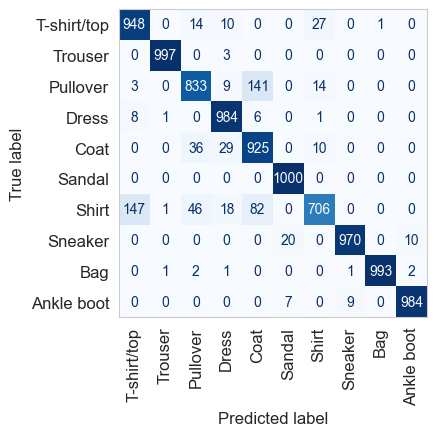

In [66]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

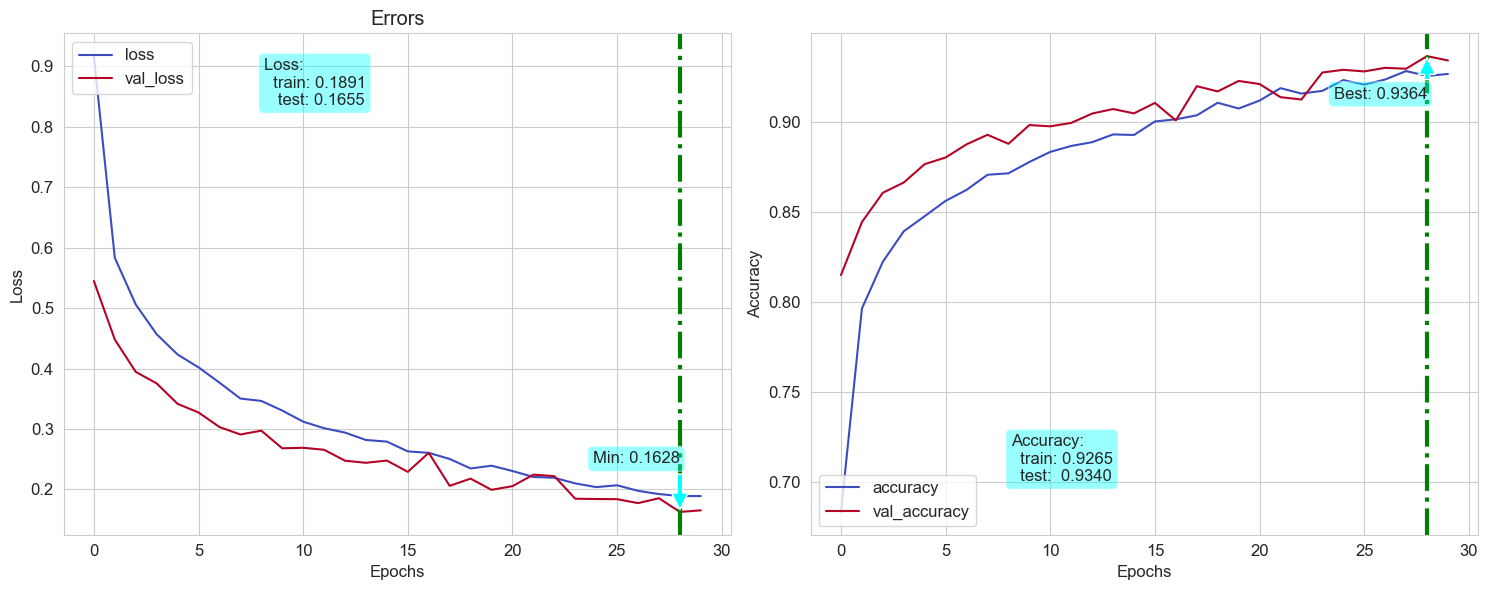

In [67]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [68]:
initializer = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer = tf.keras.regularizers.L2(0.05)

dor1 = 0.1
dor2 = 0.2

model = tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                             #Set-1
                             tf.keras.layers.Dense(196, kernel_initializer=initializer
                                                   # kernel_regularizer=regularizer
                                                   ),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.LeakyReLU(),
                             tf.keras.layers.Dropout(dor1),

                             #Set-2
                             tf.keras.layers.Dense(49, kernel_initializer=initializer
                                                   # kernel_regularizer=regularizer
                                                   ),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.LeakyReLU(),
                             tf.keras.layers.Dropout(dor2),
                             tf.keras.layers.Dense(10, kernel_initializer=initializer
                                                   # kernel_regularizer=regularizer
                                                   )])

In [69]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [76]:
tf.keras.callbacks.ReduceLROnPlateau?

In [81]:
#Call Back:
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True
)

chkpt_filepath = 'all_in.keras'
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=True,
    save_weights_only=False,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=MIN_LR
)

In [82]:
history = model.fit(train_ds, validation_data=test_ds, callbacks=[tb_callback,chkpt_callback,es_callback,lr_callback], epochs=EPOCHS)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9575 - loss: 0.1154 - val_accuracy: 0.9332 - val_loss: 0.2029 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9589 - loss: 0.1122 - val_accuracy: 0.9007 - val_loss: 0.3223 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9566 - loss: 0.1180 - val_accuracy: 0.9433 - val_loss: 0.1464 - learning_rate: 0.0010
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9574 - loss: 0.1120 - val_accuracy: 0.8845 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9599 - loss: 0.1112 - val_accuracy: 0.9032 - val_loss: 0.3186 - learning_rate: 0.0010
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9582 - loss: 0.1123 - val_accuracy: 0.9151 - val_loss: 0.2649 - learning_rate: 0.0010
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9579 - loss: 0.1083 -

In [83]:
model.evaluate(train_ds, verbose=2)  #[0.2448723465204239, 0.8982571959495544]
model.evaluate(test_ds, verbose=2)  #[0.31056174635887146, 0.8735536932945251]

157/157 - 0s - 2ms/step - accuracy: 0.9896 - loss: 0.0354
157/157 - 0s - 2ms/step - accuracy: 0.9896 - loss: 0.0354


[0.03544427827000618, 0.9896000027656555]

In [84]:
y_true, y_pred = [], []
for feat, lbls in train_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9896
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1000
           1       1.00      1.00      1.00      1000
           2       0.98      0.98      0.98      1000
           3       0.99      1.00      1.00      1000
           4       0.97      0.98      0.98      1000
           5       1.00      0.99      1.00      1000
           6       0.98      0.96      0.97      1000
           7       0.99      1.00      1.00      1000
           8       1.00      1.00      1.00      1000
           9       1.00      1.00      1.00      1000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



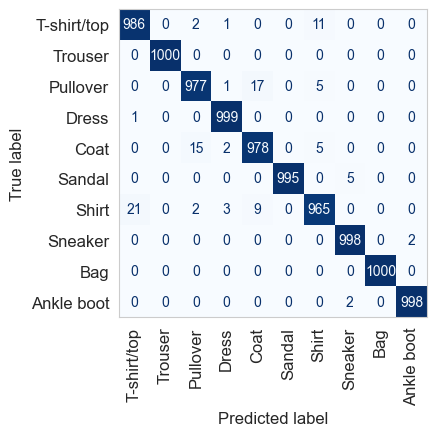

In [85]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

In [86]:
y_true, y_pred = [], []
for feat, lbls in test_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))

Accuracy: 0.9896
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1000
           1       1.00      1.00      1.00      1000
           2       0.98      0.98      0.98      1000
           3       0.99      1.00      1.00      1000
           4       0.97      0.98      0.98      1000
           5       1.00      0.99      1.00      1000
           6       0.98      0.96      0.97      1000
           7       0.99      1.00      1.00      1000
           8       1.00      1.00      1.00      1000
           9       1.00      1.00      1.00      1000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



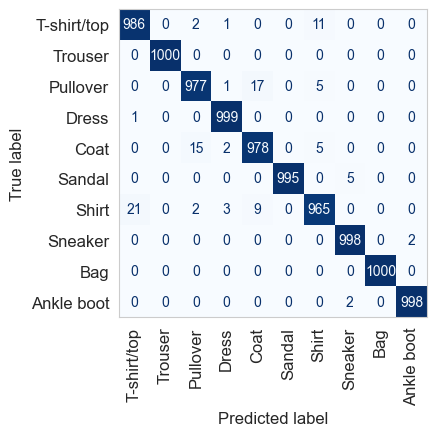

In [87]:
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)

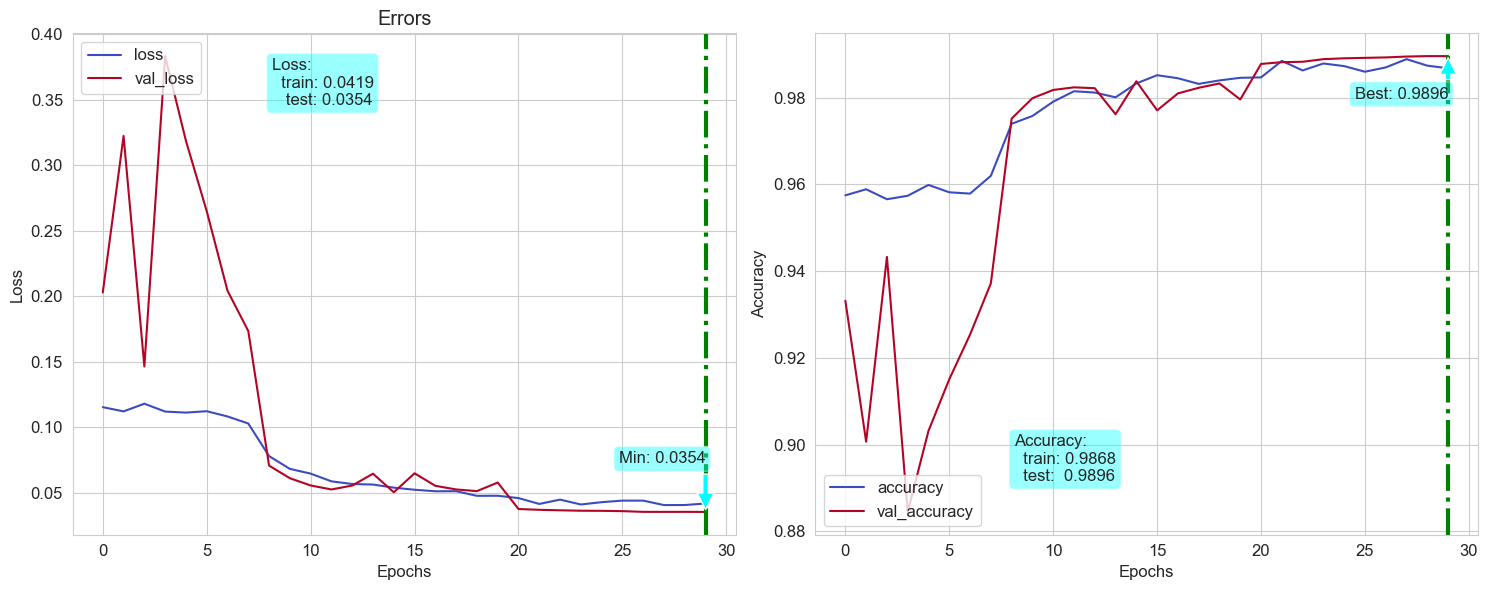

In [88]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [ ]:
initializer = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
regularizer = tf.keras.regularizers.L2(0.05)

dor1 = 0.1
dor2 = 0.2

model = tf.keras.Sequential([tf.keras.Input(shape=(784,)),
                             #Set-1
                             tf.keras.layers.Dense(196, kernel_initializer=initializer, activation='relu'
                                                   # kernel_regularizer=regularizer
                                                   ),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.LeakyReLU(),
                             tf.keras.layers.Dropout(dor1),

                             #Set-2
                             tf.keras.layers.Dense(49, kernel_initializer=initializer, activation='relu'
                                                   # kernel_regularizer=regularizer
                                                   ),
                             tf.keras.layers.BatchNormalization(),
                             tf.keras.layers.LeakyReLU(),
                             tf.keras.layers.Dropout(dor2),
                             tf.keras.layers.Dense(10, kernel_initializer=initializer
                                                   # kernel_regularizer=regularizer
                                                   )])
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
tf.keras.callbacks.ReduceLROnPlateau?
#Call Back:
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True
)

chkpt_filepath = 'all_in.keras'
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor='val_loss',
    verbose=0,
    save_best_only=True,
    save_weights_only=False,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=MIN_LR
)
history = model.fit(train_ds, validation_data=test_ds,
                    callbacks=[tb_callback, chkpt_callback, es_callback, lr_callback], epochs=EPOCHS)
model.evaluate(train_ds, verbose=2)
model.evaluate(test_ds, verbose=2)
y_true, y_pred = [], []
for feat, lbls in train_ds:  #feat=features, lbls=labels
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)
y_true, y_pred = [], []
for feat, lbls in test_ds:
    pred = model(feat).numpy()
    y_true.extend(lbls)
    y_pred.extend(pred.argmax(axis=1))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print(classification_report(y_true, y_pred))
confusion_matrix(y_true, y_pred)
fn_plot_confusion_matrix(y_true, y_pred, class_names)
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [92]:
from sklearn.metrics import f1_score
print(f1_score(y_true, y_pred, average='weighted'))

0.9895897071887643


In [93]:
from sklearn.metrics import f1_score
print(f1_score(y_true, y_pred, average='macro'))

0.989589707188764


In [94]:
from sklearn.metrics import f1_score
print(f1_score(y_true, y_pred, average='micro'))

0.9896
